In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv(r"F:\AnaPython\project2\online_retail.csv", encoding='latin1')

print(data.head())

  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  Price  Customer ID         Country  
0  01/12/2010 08:26   2.55      17850.0  United Kingdom  
1  01/12/2010 08:26   3.39      17850.0  United Kingdom  
2  01/12/2010 08:26   2.75      17850.0  United Kingdom  
3  01/12/2010 08:26   3.39      17850.0  United Kingdom  
4  01/12/2010 08:26   3.39      17850.0  United Kingdom  


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [13]:
data.shape

(541910, 8)

In [14]:
data.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

In [15]:
data.columns = data.columns.str.replace(" ", "")

In [16]:
data.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
CustomerID     135080
Country             0
dtype: int64

In [18]:
data = data.dropna(subset = ['CustomerID'])

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406830 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      406830 non-null  object 
 1   StockCode    406830 non-null  object 
 2   Description  406830 non-null  object 
 3   Quantity     406830 non-null  int64  
 4   InvoiceDate  406830 non-null  object 
 5   Price        406830 non-null  float64
 6   CustomerID   406830 non-null  float64
 7   Country      406830 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


In [20]:
data.duplicated().sum()

np.int64(5225)

In [22]:
data = data.drop_duplicates()

In [23]:
data.duplicated().sum()

np.int64(0)

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401605 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      401605 non-null  object 
 1   StockCode    401605 non-null  object 
 2   Description  401605 non-null  object 
 3   Quantity     401605 non-null  int64  
 4   InvoiceDate  401605 non-null  object 
 5   Price        401605 non-null  float64
 6   CustomerID   401605 non-null  float64
 7   Country      401605 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.6+ MB


In [27]:
data = data[data['Quantity'] > 0]
data = data[data['Price'] > 0]

In [28]:
data['Revenue'] = data['Quantity'] * data['Price']

In [30]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'], dayfirst=True)

In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392693 entries, 0 to 541909
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      392693 non-null  object        
 1   StockCode    392693 non-null  object        
 2   Description  392693 non-null  object        
 3   Quantity     392693 non-null  int64         
 4   InvoiceDate  392693 non-null  datetime64[ns]
 5   Price        392693 non-null  float64       
 6   CustomerID   392693 non-null  float64       
 7   Country      392693 non-null  object        
 8   Revenue      392693 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB


In [32]:
data['Country'].value_counts().head(10)

Country
United Kingdom    349203
Germany             9025
France              8327
EIRE                7226
Spain               2479
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1453
Australia           1181
Name: count, dtype: int64

In [34]:
data.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head()

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
Name: Revenue, dtype: float64

In [35]:
data['Month'] = data['InvoiceDate'].dt.month
data.groupby('Month')['Revenue'].sum()

Month
1      568101.310
2      446084.920
3      594081.760
4      468374.331
5      677355.150
6      660046.050
7      598962.901
8      644051.040
9      950690.202
10    1035642.450
11    1156205.610
12    1087631.170
Name: Revenue, dtype: float64

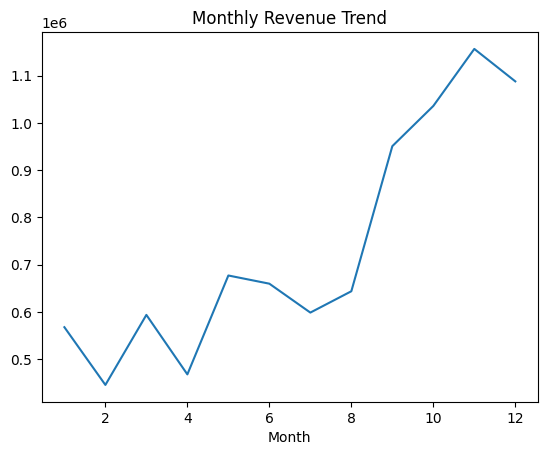

In [36]:
data.groupby('Month')['Revenue'].sum().plot()

plt.title("Monthly Revenue Trend")
plt.show()

In [37]:
today = data['InvoiceDate'].max()

In [39]:
rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (today - x.max()).days,
    'Invoice': 'count',
    'Revenue': 'sum'
})

In [40]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [41]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'], 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [42]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [43]:
def segment_customer(row):
    
    if row['RFM_Score'] == '555':
        return "Best Customers"
    
    elif int(row['F_score']) >= 4:
        return "Loyal Customers"
    
    elif int(row['R_score']) <= 2:
        return "At Risk"
    
    else:
        return "Regular Customers"

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

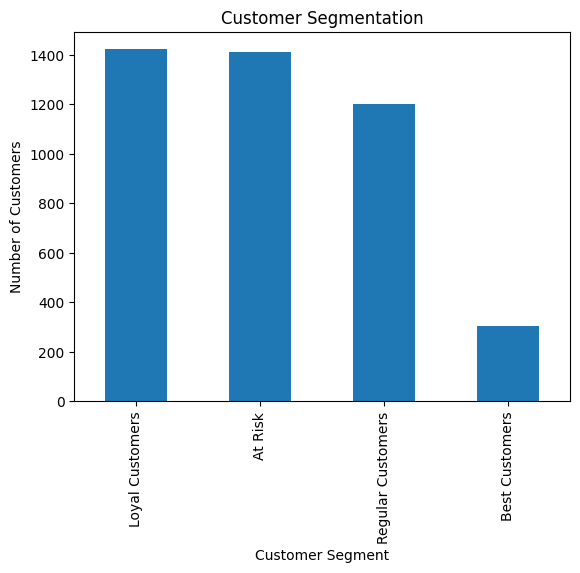

In [44]:
rfm['Segment'].value_counts().plot(kind='bar')

plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

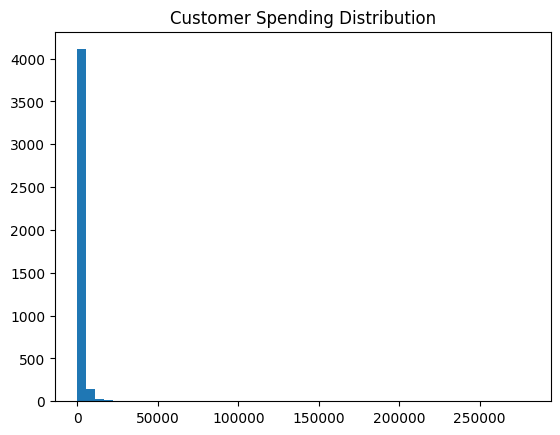

In [45]:
plt.hist(rfm['Monetary'], bins=50)

plt.title("Customer Spending Distribution")

plt.show()

In [46]:
at_risk = rfm[rfm['Segment'] == 'At Risk']

at_risk.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,325,1,77183.60,1,1,5,115,At Risk
12348.0,74,31,1797.24,2,3,4,234,At Risk
12350.0,309,17,334.40,1,2,2,122,At Risk
12353.0,203,4,89.00,1,1,1,111,At Risk
12355.0,213,13,459.40,1,1,2,112,At Risk


In [54]:
data['InvoiceDate'] = pd.to_datetime(
    data['InvoiceDate'],
    dayfirst=True,
    format='mixed',
    errors='coerce'
)

data['InvoiceDate'] = data['InvoiceDate'].dt.strftime('%Y-%m-%d')

data['CustomerID'] = data['CustomerID'].astype('Int64')

data.to_csv("Clean_Online_retail.csv", index=False)